In [6]:
# Download the FlickrLogos-27 dataset and decompress it
#######################################################

try:
    import wget
except ImportError:
    import pip
    pip.main(['install', 'wget'])
    import wget
    
import tarfile
import os

data_dir = '/workspaces/proyecto12-grupo2/data'
image_file_tar_gz = 'flickr_logos_27_dataset_images.tar.gz'
_URL = 'http://image.ntua.gr/iva/datasets/flickr_logos/flickr_logos_27_dataset.tar.gz'

if not os.path.exists(os.path.join(data_dir, 'flickr_logos_27_dataset.tar.gz')):
    print(f"Downloading original dataset in {data_dir}...")
    wget.download(_URL, out=data_dir)

    # Decompress the dataset
    print("Decompressing dataset...")
    file = tarfile.open(os.path.join(data_dir, 'flickr_logos_27_dataset.tar.gz'))
    file.extractall(data_dir)
    file.close()

    # Decompress images dataset
    print("Decompressing images...")
    file = tarfile.open(os.path.join(data_dir, 'flickr_logos_27_dataset', image_file_tar_gz))
    file.extractall(os.path.join(data_dir, 'flickr_logos_27_dataset'))
    file.close()

    print("All done!")
else:
    print("FlickrLogos-27 dataset already exists. Review the data directory.")


FlickrLogos-27 dataset already exists. Review the data directory.


In [7]:
# Process the FlickrLogos-27 dataset to YOLOv8 format
#####################################################

import os
import shutil
try:
    import pandas as pd
except ImportError:
    import pip
    pip.main(['install', 'pandas'])
    import pandas as pd
import cv2
import numpy as np
try:
    from sklearn.model_selection import train_test_split
except ImportError:
    import pip
    pip.main(['install', 'scikit-learn'])
    from sklearn.model_selection import train_test_split

# --- CONFIGURATION ---
WORKING_DIR = '/workspaces/proyecto12-grupo2/data/flickr_logos_27_dataset'
BASE_IMG_DIR = 'flickr_logos_27_dataset_images'
TRAIN_ANNOT = 'flickr_logos_27_dataset_training_set_annotation.txt'
OUTPUT_BASE = 'datasets/flickr27_yolov8'

# --- 1. LOAD AND CLEAN DATA ---
print("📋 Cargando anotaciones...")
df_all = pd.read_csv(os.path.join(WORKING_DIR, TRAIN_ANNOT), sep=r'\s+', header=None)
# Remove duplicates (images appear in multiple subsets with the same boxes)
df_clean = df_all.drop_duplicates(subset=[0, 1, 3, 4, 5, 6]).copy()
print(f"✅ Registros: {len(df_clean)} (eliminados {len(df_all)-len(df_clean)} duplicados)")

brand_classes = sorted(df_clean[1].unique().tolist())
class_map = {name: i for i, name in enumerate(brand_classes)}
print(f"🏷️  Clases detectadas: {len(brand_classes)}")

# --- 2. TRAIN/VAL SPLIT (80/20) ---
print("\n✂️  Dividiendo dataset...")
unique_filenames = df_clean[0].unique()
train_imgs, val_imgs = train_test_split(unique_filenames, test_size=0.2, random_state=42)
print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)}")

def process_split(filenames, split_name):
    img_out = os.path.join(WORKING_DIR, OUTPUT_BASE, 'images', split_name)
    lbl_out = os.path.join(WORKING_DIR, OUTPUT_BASE, 'labels', split_name)
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)
    
    processed = 0
    for img_name in filenames:
        src_path = os.path.join(WORKING_DIR, BASE_IMG_DIR, img_name)
        img = cv2.imread(src_path)
        if img is None: 
            continue
        h, w = img.shape[:2]
        img_boxes = df_clean[df_clean[0] == img_name]
        label_path = os.path.join(lbl_out, img_name.rsplit('.', 1)[0] + ".txt")
        
        with open(label_path, 'w') as f:
            for _, row in img_boxes.iterrows():
                brand = row[1]
                x1, y1, x2, y2 = float(row[3]), float(row[4]), float(row[5]), float(row[6])
                # Normalize to YOLO format
                f.write(f"{class_map[brand]} {((x1+x2)/2)/w:.6f} {((y1+y2)/2)/h:.6f} {(x2-x1)/w:.6f} {(y2-y1)/h:.6f}\n")
        shutil.copy2(src_path, os.path.join(img_out, img_name))
        processed += 1
    return processed

# --- 3. EXECUTE & YAML ---
print("\n🔄 Procesando splits...")
train_count = process_split(train_imgs, 'train')
val_count = process_split(val_imgs, 'val')
print(f"✅ Train: {train_count} imágenes | Val: {val_count} imágenes")

yaml_path = os.path.join(WORKING_DIR, OUTPUT_BASE, 'flickr27_yolov8.yaml')
with open(yaml_path, 'w') as f:
    f.write(f"path: {os.path.join(WORKING_DIR, OUTPUT_BASE)}\ntrain: images/train\nval: images/val\nnames:\n")
    for i, name in enumerate(brand_classes): 
        f.write(f"  {i}: {name}\n")

print(f"\n✅ Dataset listo: {OUTPUT_BASE}")
print(f"📝 Config YAML: {yaml_path}")
print("🚀 Listo para entrenar YOLOv8!")

📋 Cargando anotaciones...
✅ Registros: 1261 (eliminados 3275 duplicados)
🏷️  Clases detectadas: 27

✂️  Dividiendo dataset...
Train: 647 | Val: 162

🔄 Procesando splits...
✅ Train: 647 imágenes | Val: 162 imágenes

✅ Dataset listo: datasets/flickr27_yolov8
📝 Config YAML: /workspaces/proyecto12-grupo2/data/flickr_logos_27_dataset/datasets/flickr27_yolov8/flickr27_yolov8.yaml
🚀 Listo para entrenar YOLOv8!


In [8]:
# Train the YOLOv8 model with optimized hyperparameters for precision
#####################################################################
from ultralytics import YOLO
import os

# Define configuration paths (same as Cell 2)
WORKING_DIR = '/workspaces/proyecto12-grupo2/data/flickr_logos_27_dataset'
OUTPUT_BASE = 'datasets/flickr27_yolov8'

# Check if dataset has been processed
label_path = os.path.join(WORKING_DIR, OUTPUT_BASE, 'labels', 'val')
if not os.path.exists(label_path):
    print("❌ ERROR: Dataset not processed!")
    print(f"Expected path: {label_path}")
    print("\n⚠️  You need to process the dataset first!")
    print("👉 Execute these cells in order:")
    print("   1. Cell 1 - Download dataset")
    print("   2. Cell 2 - Process dataset")
    print("   3. Cell 3 - Train model (this cell)")
    raise FileNotFoundError(f"Dataset not processed yet. Please execute Cell 1 and Cell 2 first.")

files = os.listdir(label_path)
if len(files) == 0:
    print("ERROR: The validation labels folder is empty!")
    print("⚠️  Please execute Cell 2 (Process the dataset) again!")
    raise RuntimeError("Dataset folder is empty. Execute Cell 2.")
else:
    print(f"✅ Labels encontrados: {len(files)}")
    with open(os.path.join(label_path, files[0]), 'r') as f:
        print(f"\n📄 Ejemplo de label ({files[0]}):")
        print(f.read())

# LOAD MODEL: Load the YOLOv8 model weights (CAMBIADO A YOLOV8S PARA GPU 4GB)
print("\n📦 Cargando YOLOv8s (Small - optimizado para GPU 4GB)...")
model = YOLO('yolov8s.pt')

# TRAIN: Begin training with optimized hyperparameters for precision
print("\n🚀 Iniciando entrenamiento YOLOv8 con GPU...\n")

results = model.train(
    workers=4,          # REDUCIDO: Menos workers para GPU pequeña
    data=os.path.join(WORKING_DIR, OUTPUT_BASE, 'flickr27_yolov8.yaml'),
    epochs=50,
    imgsz=416,
    batch=4,            # REDUCIDO: Batch size más pequeño para GPU 4GB
    cache='ram',        # AÑADIDO: Cache en RAM para reducir carga en GPU
    # --- PRECISION OPTIMIZATION ---
    patience=25,        # EARLY STOPPING: Stop training if validation doesn't improve for 25 epochs
    device=0,           # USE GPU: Device 0 for GPU acceleration
    optimizer='SGD',    # Use SGD optimizer for better convergence
    lr0=0.01,           # Initial learning rate
    lrf=0.01,           # Final learning rate (cosine annealing)
    momentum=0.937,     # Momentum for SGD optimizer
    weight_decay=0.0005,# L2 regularization to prevent overfitting
    warmup_epochs=3.0,  # Warmup epochs for stable training start
    warmup_momentum=0.8,# Initial momentum during warmup
    warmup_bias_lr=0.1, # Initial bias learning rate during warmup
    # --- ENHANCED TRAINING HYPERPARAMETERS ---
    close_mosaic=15,    # CLOSE MOSAIC: Disable mosaic augmentation in final 15 epochs
    cls=2.5,            # CLASS LOSS WEIGHT: Increases importance of classification
    box=7.5,            # BOX LOSS WEIGHT: Higher weight for accurate bounding box predictions
    # --- ADVANCED IMAGE AUGMENTATION ---
    degrees=20.0,       # ROTATION: Rotate images up to 20 degrees
    translate=0.1,      # TRANSLATE: Shift images horizontally/vertically by 10%
    scale=0.5,          # SCALE: Scale images between 50%-150%
    shear=8.0,          # SHEAR: Apply shear transformations
    perspective=0.0015, # PERSPECTIVE: Apply perspective transformations
    flipud=0.5,         # VERTICAL FLIP: 50% chance of vertical flip
    fliplr=0.5,         # HORIZONTAL FLIP: 50% chance of horizontal flip
    mosaic=1.0,         # MOSAIC: 100% mosaic augmentation during training
    mixup=0.1,          # MIXUP: Mix images and labels for better generalization
    hsv_h=0.015,        # HSV HUE: Adjust hue by 0-15%
    hsv_s=0.7,          # HSV SATURATION: Adjust saturation by 0-70%
    hsv_v=0.4,          # HSV VALUE: Adjust brightness by 0-40%
    # --- PATH AND OUTPUT SETTINGS ---
    project='/workspaces/proyecto12-grupo2/models', 
    name='models_mgg',
    exist_ok=True,
    save=True,
    save_period=10,     # Save checkpoint every 10 epochs
    val=True,           # Enable validation during training
    plots=True,         # Generate training plots
    verbose=True        # Show detailed training logs
)

print("\n🎉 Training completed with precision optimization!")
print(f"📊 Results saved in: /workspaces/proyecto12-grupo2/models/models_mgg")
print(f"📈 Best model: /workspaces/proyecto12-grupo2/models/models_mgg/weights/best.pt")

✅ Labels encontrados: 162

📄 Ejemplo de label (1107796028.txt):
3 0.466250 0.622000 0.377500 0.244000


📦 Cargando YOLOv8s (Small - optimizado para GPU 4GB)...

🚀 Iniciando entrenamiento YOLOv8 con GPU...

New https://pypi.org/project/ultralytics/8.4.9 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.8 🚀 Python-3.11.14 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=15, cls=2.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/workspaces/proyecto12-grupo2/data/flickr_logos_27_dataset/datasets/flickr27_yolov8/flickr27_yolov8.yaml, degrees=20.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.

📦 Cargando modelo: /workspaces/proyecto12-grupo2/models/models_mgg/weights/best.pt
✅ Imágenes de validación: 162

🎨 Visualizando 4 detecciones...

📸 3571331128.jpg:
   - Nbc: 0.91

📸 4524715145.jpg:
   - Puma: 0.79
   - Puma: 0.36

📸 3006946827.jpg:
   - Apple: 0.85

📸 4763847308.jpg:
   - Adidas: 0.75
   - Adidas: 0.53
   - Adidas: 0.53
   - Adidas: 0.45
   - Adidas: 0.40
   - Adidas: 0.36
   - Adidas: 0.36



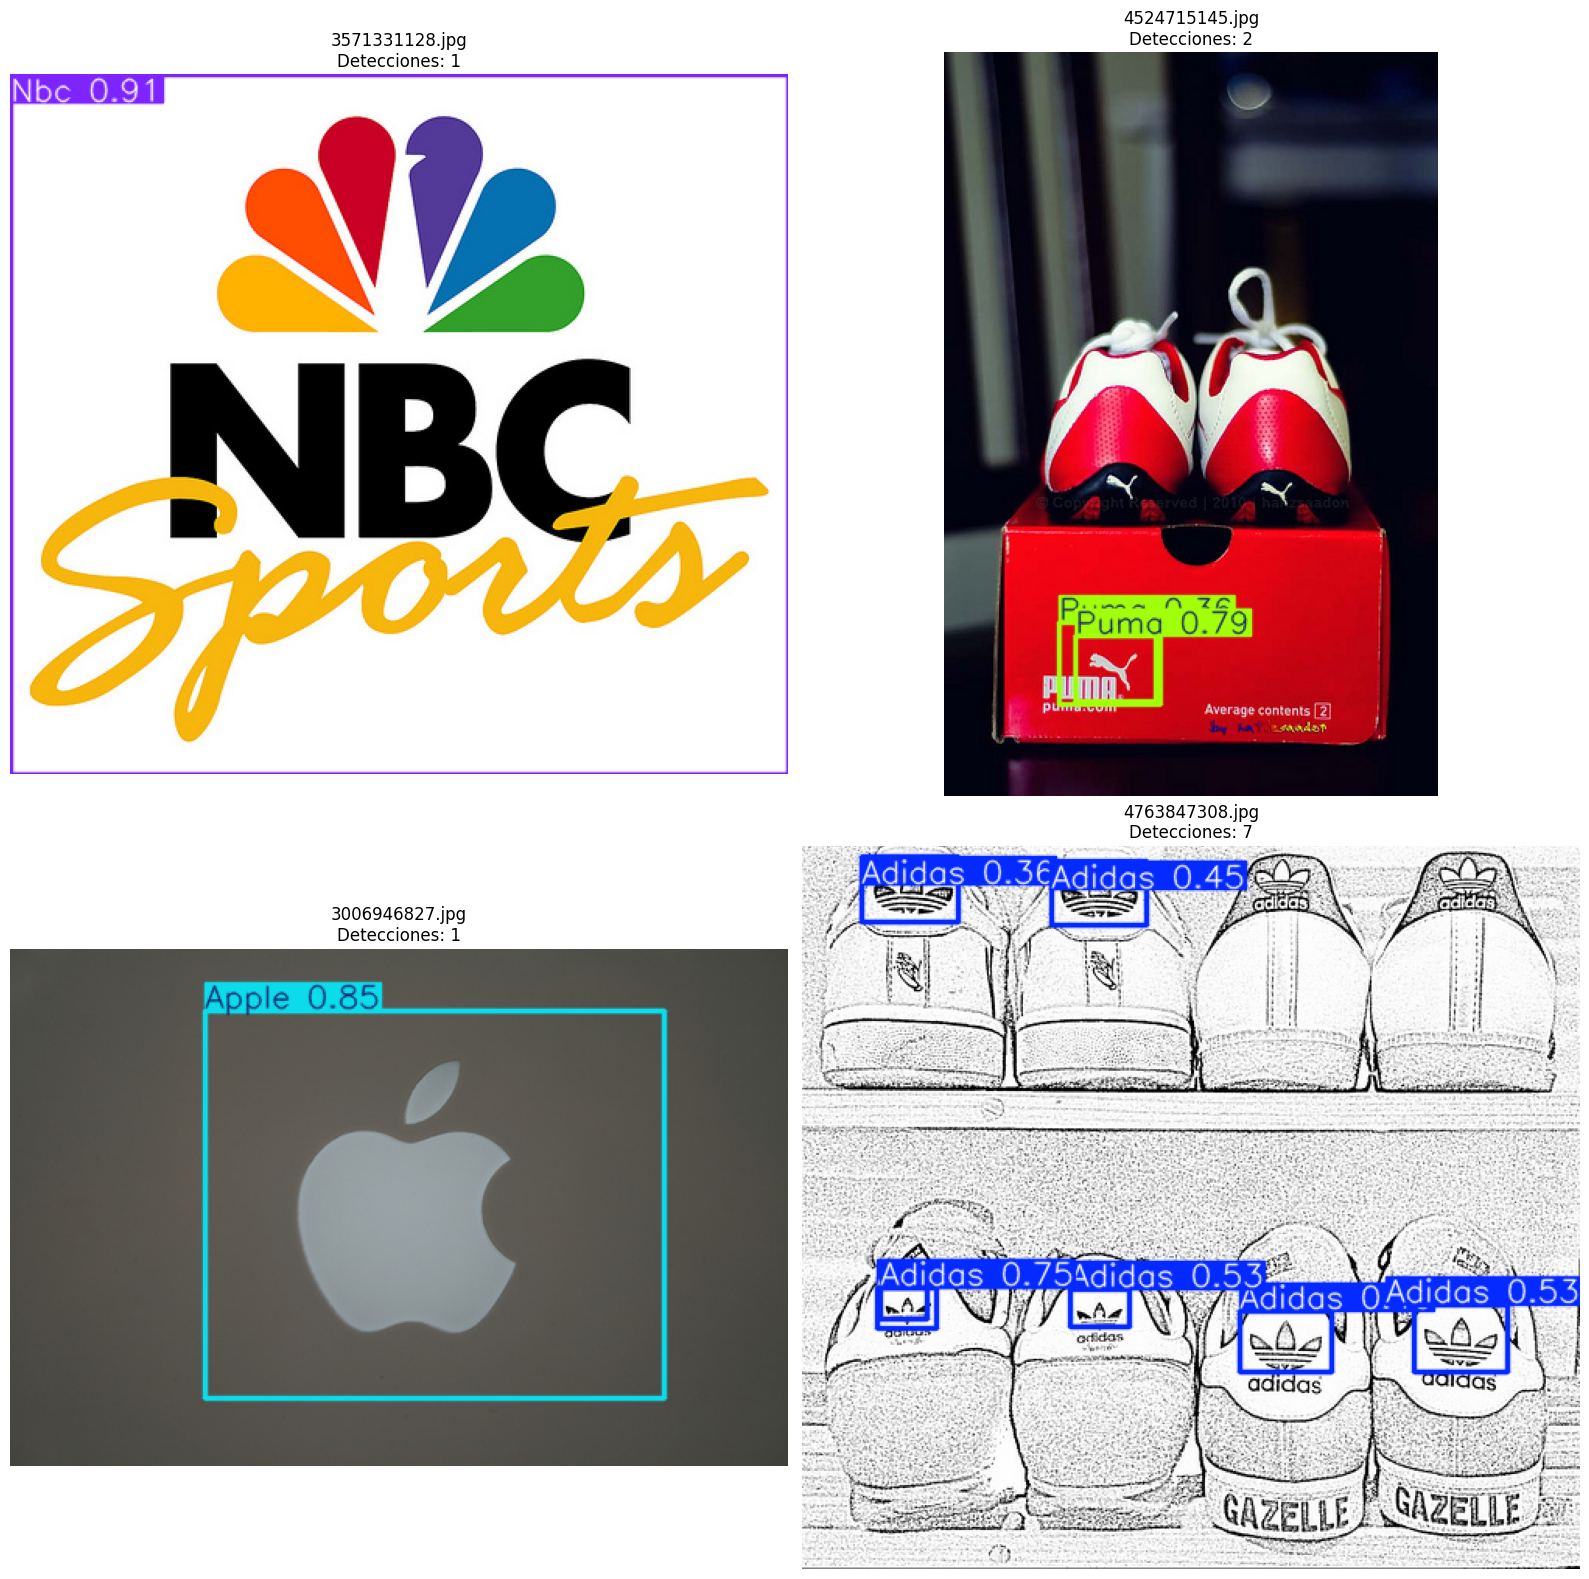

✅ Visualización completada!


In [9]:
# ============================================
# PARTE 4: Validación Visual del Modelo
# ============================================

import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Configurar matplotlib para Jupyter
%matplotlib inline

# --- CONFIGURACIÓN (mismas rutas que Celda 2 y 3) ---
WORKING_DIR = '/workspaces/proyecto12-grupo2/data/flickr_logos_27_dataset'
OUTPUT_BASE = 'datasets/flickr27_yolov8'

# --- 1. CARGAR MEJOR MODELO ---
model_path = '/workspaces/proyecto12-grupo2/models/models_mgg/weights/best.pt'

if not os.path.exists(model_path):
    print(f"❌ ERROR: Modelo no encontrado en {model_path}")
    print("⚠️  Debes entrenar el modelo primero (Celda 3)")
    raise FileNotFoundError(f"Modelo no encontrado. Por favor ejecuta la Celda 3 primero.")

print(f"📦 Cargando modelo: {model_path}")
model = YOLO(model_path)

# --- 2. CONFIGURAR PATHS DE VALIDACIÓN ---
val_images_path = os.path.join(WORKING_DIR, OUTPUT_BASE, 'images', 'val')
all_val_images = [os.path.join(val_images_path, f) for f in os.listdir(val_images_path) 
                  if f.endswith(('.jpg', '.png', '.jpeg'))]

print(f"✅ Imágenes de validación: {len(all_val_images)}")

if len(all_val_images) == 0:
    print("❌ ERROR: No se encontraron imágenes de validación!")
    print(f"Ruta buscada: {val_images_path}")
    raise FileNotFoundError("Ejecuta Celda 2 primero para procesar el dataset.")
else:
    # --- 3. SELECCIÓN ALEATORIA ---
    num_samples = min(4, len(all_val_images))  # Máximo 4 o menos si hay pocas imágenes
    sample_images = random.sample(all_val_images, num_samples)
    
    # --- 4. VISUALIZACIÓN ---
    print(f"\n🎨 Visualizando {num_samples} detecciones...\n")
    
    fig, axs = plt.subplots(2, 2, figsize=(16, 16))
    axs = axs.flatten()
    
    for i, img_path in enumerate(sample_images):
        # Detectar con confianza 0.25
        results = model(img_path, conf=0.25, verbose=False)
        
        # Plotear resultados
        res_plotted = results[0].plot()
        
        # Convertir BGR a RGB para matplotlib
        res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
        
        # Mostrar en subplot
        axs[i].imshow(res_rgb)
        img_name = os.path.basename(img_path)
        axs[i].set_title(f"{img_name}\nDetecciones: {len(results[0].boxes)}", fontsize=12)
        axs[i].axis('off')
        
        # Imprimir info de detecciones
        if len(results[0].boxes) > 0:
            print(f"📸 {img_name}:")
            for box in results[0].boxes:
                cls = int(box.cls[0])
                conf = float(box.conf[0])
                brand = model.names[cls]
                print(f"   - {brand}: {conf:.2f}")
        else:
            print(f"📸 {img_name}: Sin detecciones")
        print()
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualización completada!")

In [ ]:
# ============================================
# PARTE 5: Evaluación de Métricas del Modelo
# ============================================

from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 1. CARGAR MODELO ENTRENADO ---
model_path = '/workspaces/proyecto12-grupo2/models/models_mgg/weights/best.pt'
model = YOLO(model_path)

print("🔍 EVALUANDO MODELO...\n")

# --- 2. VALIDAR MODELO (genera métricas detalladas) ---
WORKING_DIR = '/workspaces/proyecto12-grupo2/data/flickr_logos_27_dataset'
OUTPUT_BASE = 'datasets/flickr27_yolov8'
yaml_path = os.path.join(WORKING_DIR, OUTPUT_BASE, 'flickr27_yolov8.yaml')

metrics = model.val(data=yaml_path, conf=0.25, iou=0.5)

# --- 3. MOSTRAR MÉTRICAS PRINCIPALES ---
print("=" * 60)
print("📊 MÉTRICAS DE PRECISIÓN DEL MODELO")
print("=" * 60)
print(f"mAP50 (IoU=0.5):      {metrics.box.map50:.4f}   {'✅' if metrics.box.map50 > 0.5 else '⚠️'}")
print(f"mAP50-95:             {metrics.box.map:.4f}   {'✅' if metrics.box.map > 0.3 else '⚠️'}")
print(f"Precision:            {metrics.box.mp:.4f}   {'✅' if metrics.box.mp > 0.7 else '⚠️'}")
print(f"Recall:               {metrics.box.mr:.4f}   {'✅' if metrics.box.mr > 0.6 else '⚠️'}")
print("=" * 60)

# --- 4. LEER HISTORIAL DE ENTRENAMIENTO ---
results_path = '/workspaces/proyecto12-grupo2/models/models_mgg/results.csv'
if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip()  # Limpiar espacios en nombres
    
    print("\n📈 EVOLUCIÓN DURANTE EL ENTRENAMIENTO:\n")
    
    # Mostrar últimas 5 épocas
    print(df[['epoch', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 
              'metrics/precision(B)', 'metrics/recall(B)']].tail(5).to_string(index=False))
    
    # --- 5. GRAFICAR EVOLUCIÓN ---
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # mAP50
    axes[0, 0].plot(df['epoch'], df['metrics/mAP50(B)'], 'b-', linewidth=2)
    axes[0, 0].set_title('mAP50 (IoU=0.5)', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('mAP50')
    axes[0, 0].grid(True, alpha=0.3)
    
    # mAP50-95
    axes[0, 1].plot(df['epoch'], df['metrics/mAP50-95(B)'], 'g-', linewidth=2)
    axes[0, 1].set_title('mAP50-95', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('mAP50-95')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    axes[1, 0].plot(df['epoch'], df['metrics/precision(B)'], 'r-', linewidth=2)
    axes[1, 0].set_title('Precision', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 1].plot(df['epoch'], df['metrics/recall(B)'], 'm-', linewidth=2)
    axes[1, 1].set_title('Recall', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Evaluación completada!")
else:
    print(f"\n⚠️  No se encontró {results_path}")

# --- 6. INTERPRETACIÓN ---
print("\n" + "=" * 60)
print("📚 INTERPRETACIÓN DE MÉTRICAS:")
print("=" * 60)
print("• mAP50 > 0.5:       Modelo bueno")
print("• mAP50-95 > 0.3:    Modelo preciso en diferentes IoU")
print("• Precision > 0.7:   Pocas detecciones falsas")
print("• Recall > 0.6:      Detecta la mayoría de objetos")
print("=" * 60)

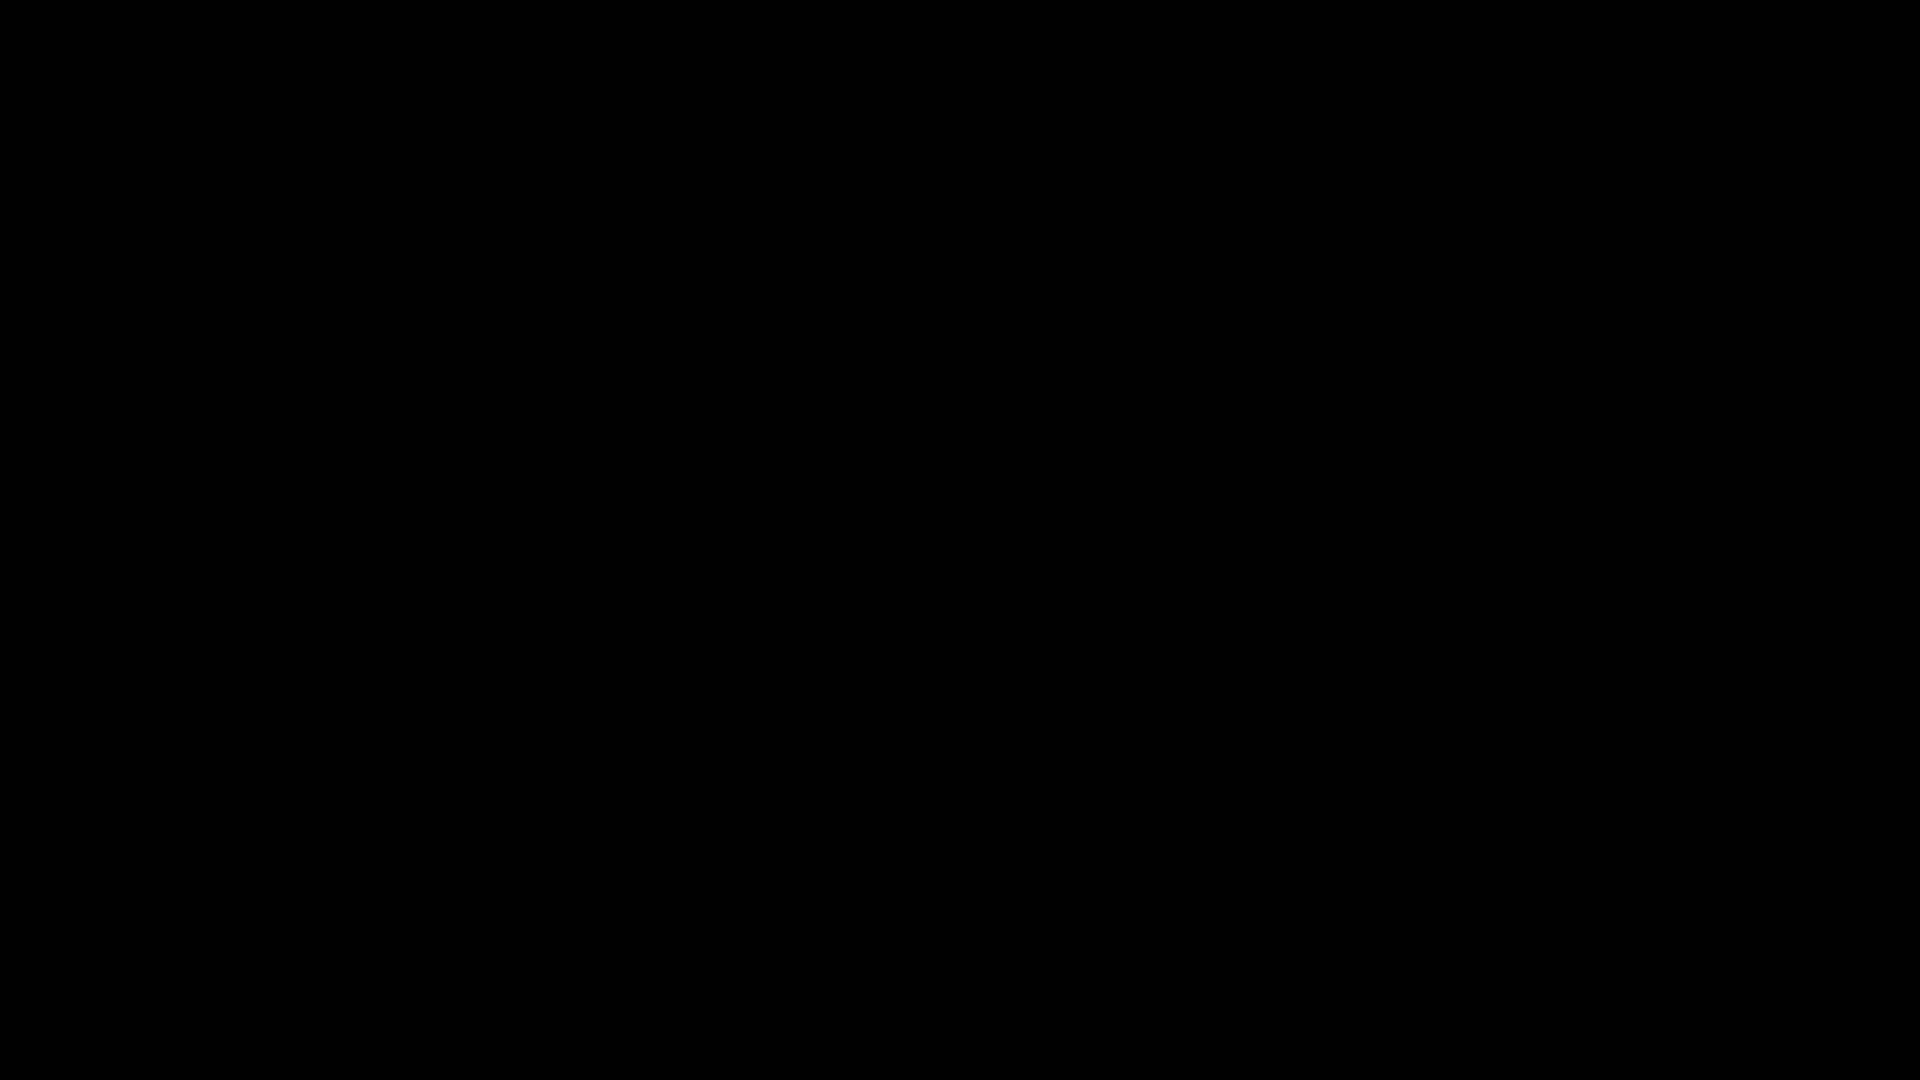

Speed: 6.8ms preprocess, 54.0ms inference, 6.3ms postprocess per image at shape (1, 3, 256, 416)


In [10]:
# Test with video
#################
from ultralytics import YOLO
import cv2
from IPython.display import display, Image, clear_output

model = YOLO('/workspaces/proyecto12-grupo2/models/models_mgg/weights/best.pt')
source_url = 'https://www.youtube.com/watch?v=-_-oi1Apm8I'

results = model.predict(source=source_url, conf=0.45, stream=True)

for r in results:
    annotated_frame = r.plot()
    
    # Encode the frame as a JPEG to display it in the notebook
    _, buffer = cv2.imencode('.jpg', annotated_frame)
    
    # Clear the previous frame and show the new one
    clear_output(wait=True)
    display(Image(data=buffer))